In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [2]:
#load
X1 =np.load('data/f2/updated_inputs.npy')
y1 = np.load('data/f2/updated_outputs.npy')# log-likelihood

In [3]:
# compute mean distance
distances = pdist(X1, metric='euclidean') # compute mean distance between data

In [4]:
# Grid 2D for evaluation
n_grid   = 100
x1_range = np.linspace(X1[:,0].min(), X1[:,0].max(), n_grid)
x2_range = np.linspace(X1[:,1].min(), X1[:,1].max(), n_grid)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
x_grid_2d = np.column_stack([xx1.ravel(), xx2.ravel()])

In [5]:
# The current best
best_f = np.max(y1)
best_idx = np.argmax(y1)
print(f"the best data is: X = {X1[best_idx]}, y = {best_f:.4f}")
print('best f(x)=', best_f)

the best data is: X = [0.70263656 0.9265642 ], y = 0.6112
best f(x)= 0.6112052157614438


In [6]:
#EI (maximize)
xi = 0.1
def expected_improvement(mean, std, best_f, xi):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

In [7]:
#GP: find the optimal lengthscale
noise_assumption = 1e-4 # moderate noise
Alpha=[]
Mean=[]
STD=[]
for alpha in np.linspace(0.1, 3, 30):
    rbf_lengthscale  = alpha*distances.mean()#alpha times mean distance
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    model.fit(X1, y1)

    #GP Prediction
    post_mean, post_std = model.predict(x_grid_2d, return_std=True)

    ei_values = expected_improvement(post_mean, post_std, best_f, xi)
    #Next Point
    idx_next = np.argmax(ei_values)
    x_next   = x_grid_2d[idx_next]
    std_next = post_std[idx_next]
    y_next = post_mean[idx_next]
    Alpha.append(alpha)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

Alpha for max mean= 1.2


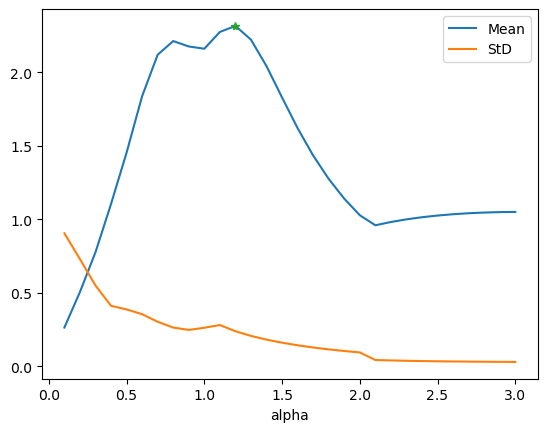

In [8]:
# plot alpha optimization
id_max = np.argmax(Mean)
plt.plot(Alpha,Mean, label='Mean')
plt.plot(Alpha,STD, label='StD')
plt.plot(Alpha[id_max], Mean[id_max], marker='*')
plt.xlabel('alpha')
plt.legend()

print('Alpha for max mean=',Alpha[id_max])

In [9]:
# re-compute maximum
alpha=Alpha[id_max]
rbf_lengthscale  = alpha*distances.mean()#max mean distance
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X1, y1)
#GP Prediction
post_mean, post_std = model.predict(x_grid_2d, return_std=True)
ei_values = expected_improvement(post_mean, post_std, best_f, xi)

In [10]:
#Next Point from EI
idx_next = np.argmax(ei_values)
x_next   = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]#Next Point

print(f"proposed query(EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}")
print('expected Y=', y_next)
print('with Std=', std_next)

#query from EI
x_next_ei = x_next
y_next_ei = y_next

proposed query(EI): x1=0.14269907, x2=0.92656420
expected Y= 2.3141987759877907
with Std= 0.2381244431892791


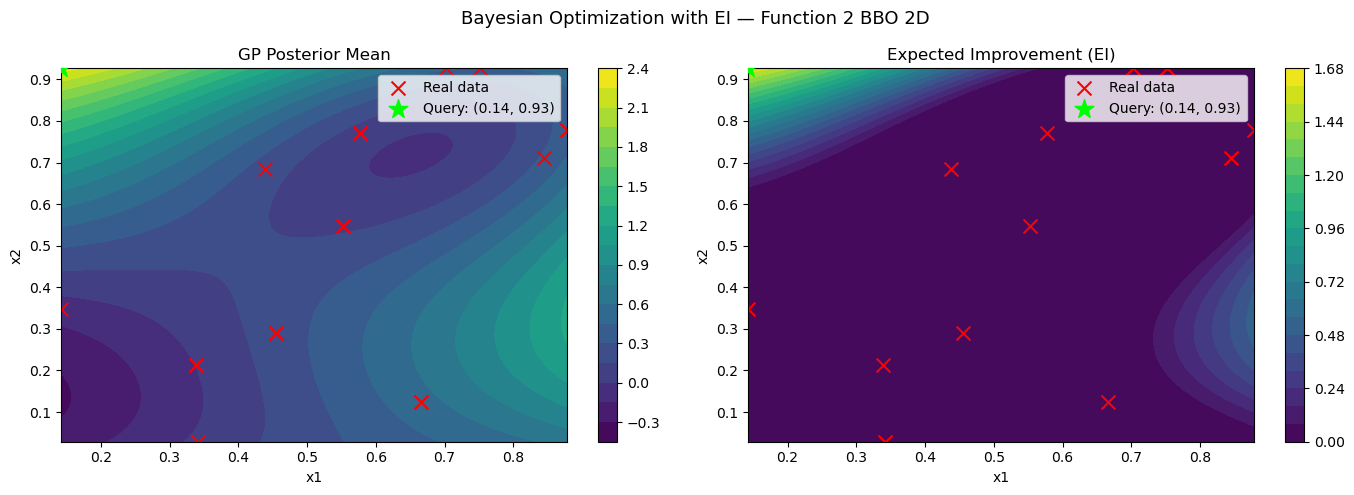

In [11]:
#graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, ei_values],
    ['GP Posterior Mean', 'Expected Improvement (EI)']):

    Z_plot = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z_plot, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X1[:,0], X1[:,1], c='red', marker='x', s=100, label='Real data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, zorder=5, label=f'Query: ({x_next[0]:.2f}, {x_next[1]:.2f})')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Bayesian Optimization with EI — Function 2 BBO 2D', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# UCB acquisition: find best k
K=[]
Mean=[]
STD=[]
for k in np.linspace(0.1, 3, 30):
    acquisition = post_mean + k * post_std
    idx_next = np.argmax(acquisition)
    x_next = x_grid_2d[idx_next]
    std_next = post_std[idx_next]
    y_next = post_mean[idx_next]
    K.append(k)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

K for max mean= 0.1


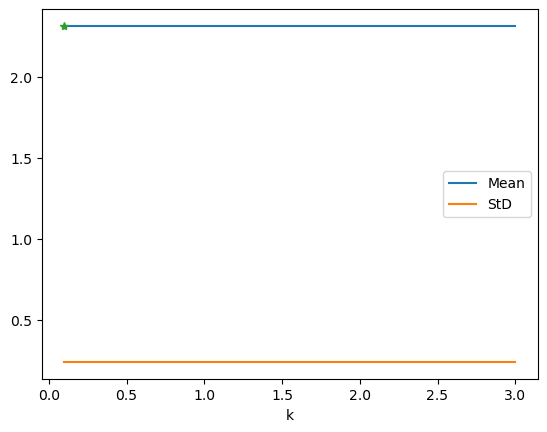

In [13]:
# plot k optimization
id_max = np.argmax(Mean)
plt.plot(K,Mean, label='Mean')
plt.plot(K,STD, label='StD')
plt.plot(K[id_max], Mean[id_max], marker='*')
plt.xlabel('k')
plt.legend()

print('K for max mean=',K[id_max])

In [14]:
# re-compute maximum
acquisition = post_mean + K[id_max] * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_2d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]

print(f"Proposed query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}")
print('expected Y=', y_next)
print('with Std=', std_next)

#query from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Proposed query (UCB): x1=0.14269907, x2=0.92656420
expected Y= 2.3141987759877907
with Std= 0.2381244431892791


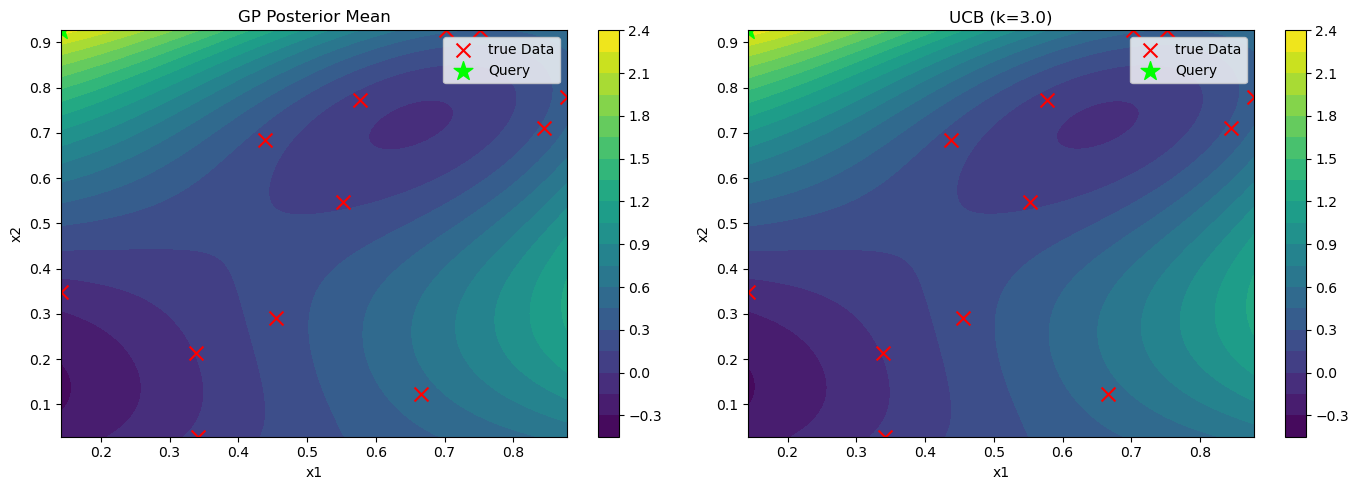

In [15]:
# Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, values, title in zip(axes,
    [post_mean, acquisition],
    ['GP Posterior Mean', f'UCB (k={k})']):
    
    Z = values.reshape(n_grid, n_grid)
    cp = ax.contourf(xx1, xx2, Z, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.scatter(X1[:,0], X1[:,1], c='red', marker='x', s=100, label='true Data')
    ax.scatter(x_next[0], x_next[1], c='lime', marker='*', s=200, label='Query')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# RSM Method
import pandas as pd
from statsmodels.formula.api import ols

In [17]:
# create dataframe
data = np.column_stack((X1,y1))
df = pd.DataFrame(data, columns=['x1', 'x2', 'y_norm'])
# fit regression model
model = ols(formula='y_norm ~ x1 + x2 + I(x1**2) + I(x2**2) + I(x1*x2)', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 y_norm   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     3.266
Date:                Sun, 13 Sep 2026   Prob (F-statistic):             0.0910
Time:                        10:18:28   Log-Likelihood:                 9.6970
No. Observations:                  12   AIC:                            -7.394
Df Residuals:                       6   BIC:                            -4.485
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2429      0.303     -0.802      0.4

In [18]:
# Optimization (Gradient Descent - Simplified)
from scipy.optimize import minimize

def objective(Xin):
    x1, x2 = Xin
    return -model.predict(pd.DataFrame({'x1': [x1], 'x2': [x2]}))[0]

initial_guess = [0.2, 0.2]
result = minimize(objective, initial_guess, bounds=[(0, 1.), (0, 1.)], method='L-BFGS-B')
optimal = result.x
print('optimal=',optimal)
print('objective (y)=',-objective(optimal))

#query from RSM
x_next_rsm = optimal
y_next_rsm = -objective(optimal)

optimal= [1. 0.]
objective (y)= 1.6137258415397118


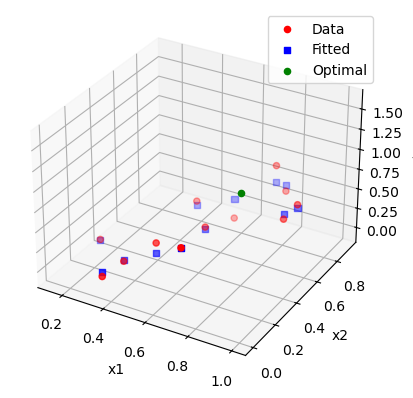

In [19]:
# Analyse the response surface and optimal
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y_norm'], c='r', marker='o', label='Data')
ax.scatter(df['x1'], df['x2'], model.fittedvalues, c='b', marker='s', label='Fitted')
ax.scatter(optimal[0], optimal[1], -objective(optimal), c='g', marker='o', label='Optimal')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.legend(loc='best')
plt.show()



In [20]:
# Choose the best option between EI, UCB and RSM
if y_next_ei >= y_next_ucb and y_next_ei >= y_next_rsm:
    x_next_out = x_next_ei
elif y_next_ucb > y_next_ei and y_next_ucb > y_next_rsm:
    x_next_out = x_next_ucb
else:
    x_next_out = x_next_rsm

# Write output file
import os
folder = 'results'
filename = 'output_F2.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f}\n")